# Unified Products Database — EDA

This notebook explores `unified_products.csv`, the merged output of the TDU
data pipeline: **20,820 rows** across **87 columns**, combining 6 supplier
sources (Rezdy, Fareharbor, Livn, CustomLinc, Ventus, Ingresso) that were
each independently flattened, verified, and schema-mapped before being
merged on a compound key of `(product_id, source)`.

Because the 6 sources have very different native schemas, most of the 87
columns are populated by only one or two sources — this notebook makes
that visible column by column, and specifically documents the handful of
"false-friend" columns where the same column name hides genuinely
different data shapes across sources (a known finding from the Stage 2
schema validation work).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')

CSV_PATH = "../unified_database/unified_products.csv"  # relative to this notebook


## 1. Overview

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Shape: 20,820 rows x 87 columns


In [3]:
df.columns.tolist()


['product_id',
 'source',
 'product_name',
 'product_price',
 'product_price_numeric',
 'availability',
 'booking_channel_code',
 'booking_lead_time',
 'breakfast_details',
 'cancellation_days',
 'cancellation_hours',
 'cancellation_type',
 'departure_date',
 'departure_time_display',
 'detail_accessibility',
 'detail_booking_notes',
 'detail_cancellation_policy',
 'detail_description',
 'detail_group_size',
 'detail_health_safety',
 'detail_highlights',
 'detail_itinerary',
 'detail_min_age',
 'detail_operating_days',
 'detail_start_time',
 'detail_start_time_range_max',
 'detail_tax_percentage',
 'detail_what_is_included',
 'detail_what_is_not_included',
 'detail_what_to_bring',
 'duration_display',
 'duration_text',
 'duration_unit_source',
 'event_code',
 'fare_types',
 'flight_type_id',
 'has_breakfast_included',
 'has_transfer_included',
 'image_count',
 'is_pickup_available',
 'is_pickup_compulsory',
 'is_seated',
 'location_city',
 'location_country',
 'location_end_source',
 '

In [4]:
df.dtypes.value_counts()


str        64
float64    18
object      5
Name: count, dtype: int64

### Missing values per column

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table


,missing_count,missing_pct
package_groups,20816,100.0
package_type,20816,100.0
transfer_name,20815,100.0
transfer_pickup_hotels,20815,100.0
transfer_id,20815,100.0
...,...,...
product_price_numeric,10,0.0
product_price,10,0.0
product_id,0,0.0
source,0,0.0


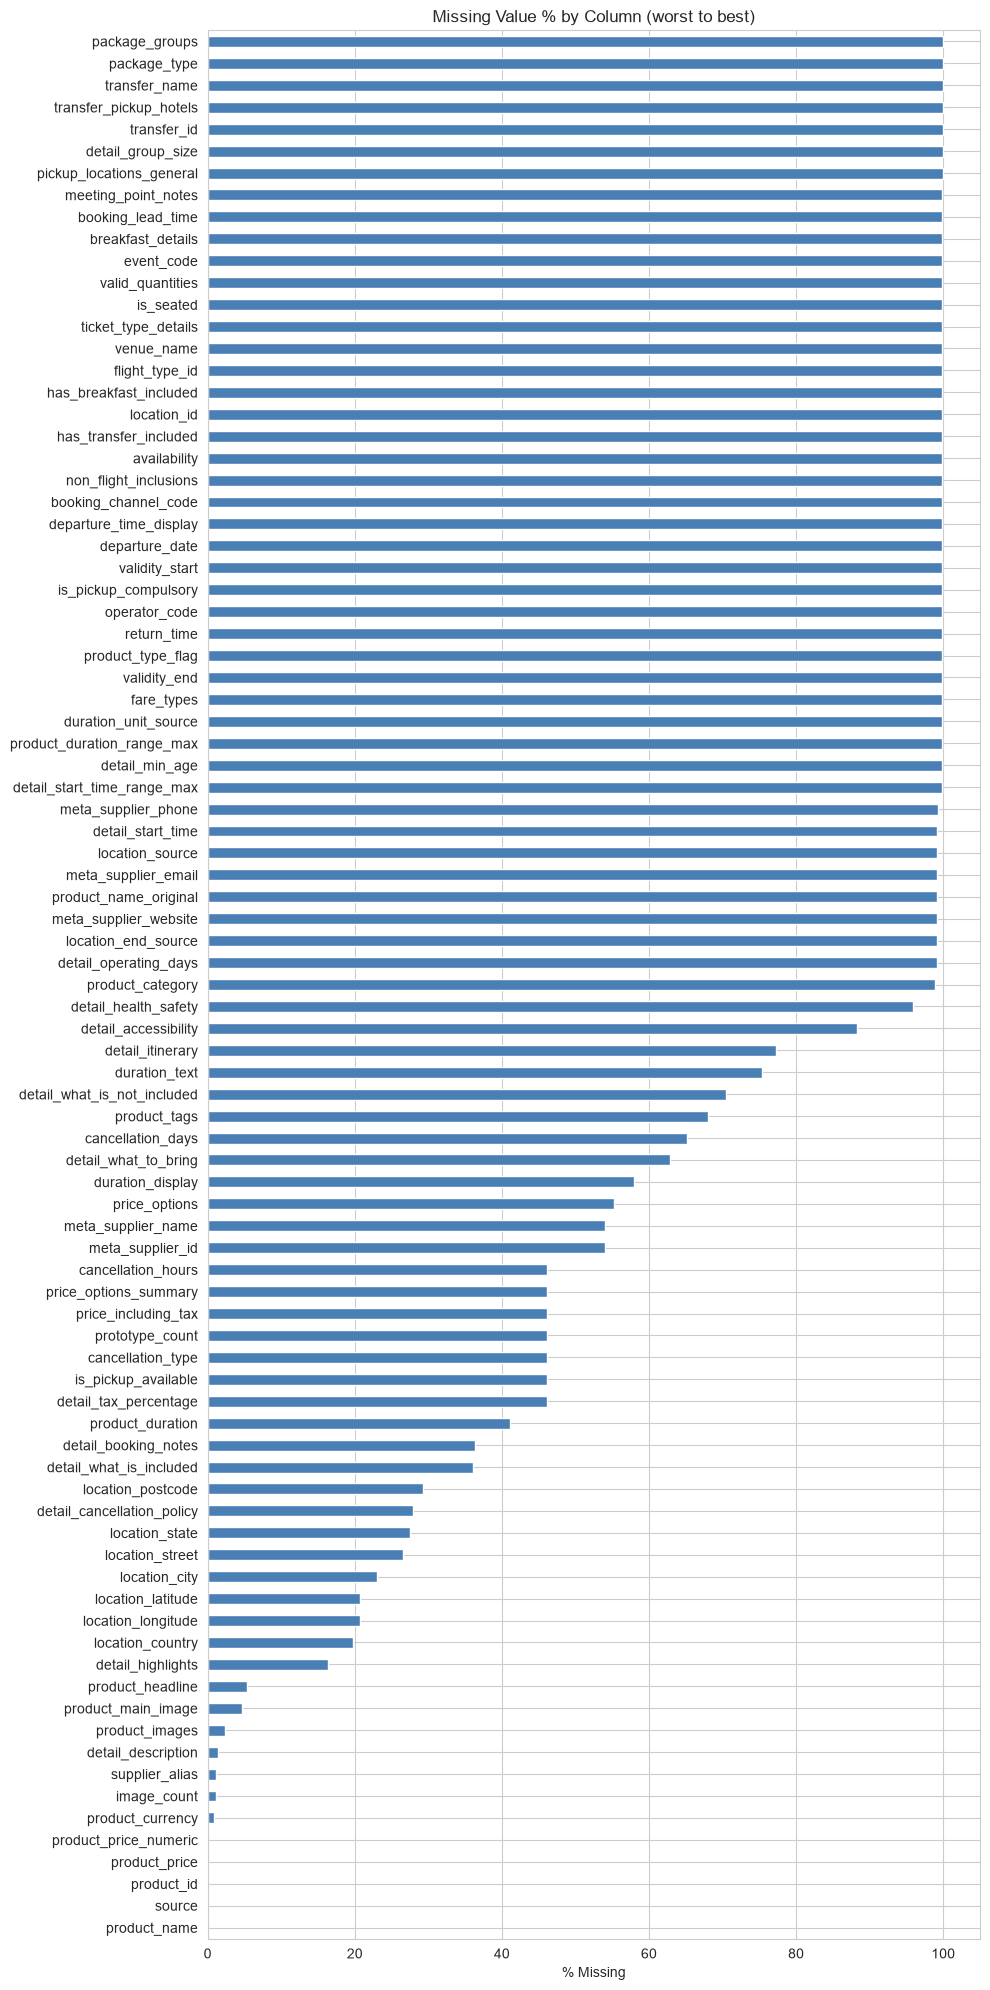

In [6]:
fig, ax = plt.subplots(figsize=(10, 20))
missing_table['missing_pct'].plot(kind='barh', ax=ax, color='#4a7fb5')
ax.set_xlabel('% Missing')
ax.set_title('Missing Value % by Column (worst to best)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Row count per source

In [7]:
source_counts = df['source'].value_counts()
source_counts


source
Fareharbor    11231
Rezdy          9363
Livn            167
CustomLinc       24
Ventus           19
Ingresso         16
Name: count, dtype: int64

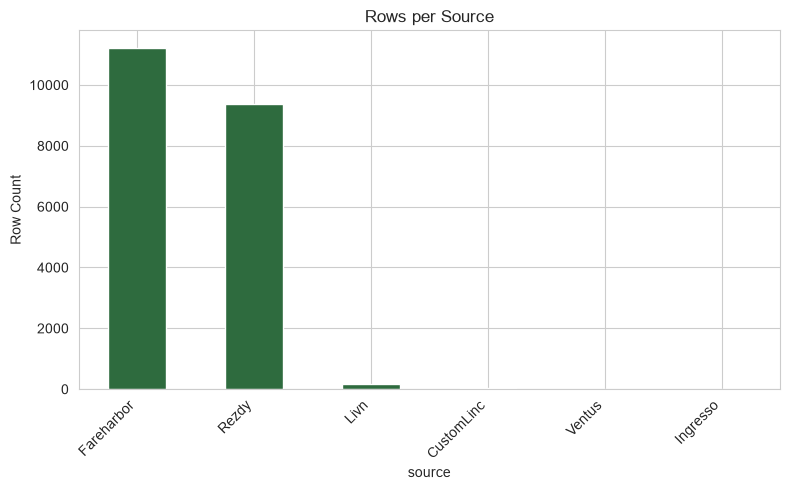

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
source_counts.plot(kind='bar', ax=ax, color='#2e6b3e')
ax.set_ylabel('Row Count')
ax.set_title('Rows per Source')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2. Column-by-Column Analysis

### 2.1 Identity & Core Fields

#### `product_id`

In [9]:
col = "product_id"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_id: 20820 non-null / 20820 (0.0% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11231
Ingresso         16
Livn            167
Rezdy          9363
Ventus           19
Name: product_id, dtype: int64

Unique values: 20820
Top 10 value counts:
product_id
PPGBNQ    1
PUFXKX    1
P0MLTT    1
PGLPWD    1
PKGUF6    1
PZZGY1    1
P03KAC    1
P3VLWV    1
P0LRPR    1
P5PNZ9    1
Name: count, dtype: int64

Sample values:
  PPGBNQ
  PUFXKX
  P0MLTT


#### `source`

In [10]:
col = "source"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


source: 20820 non-null / 20820 (0.0% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11231
Ingresso         16
Livn            167
Rezdy          9363
Ventus           19
Name: source, dtype: int64

Unique values: 6
source
Fareharbor    11231
Rezdy          9363
Livn            167
CustomLinc       24
Ventus           19
Ingresso         16
Name: count, dtype: int64

Sample values:
  Rezdy
  Rezdy
  Rezdy


#### `product_name`

In [11]:
col = "product_name"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_name: 20820 non-null / 20820 (0.0% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11231
Ingresso         16
Livn            167
Rezdy          9363
Ventus           19
Name: product_name, dtype: int64

Unique values: 19917
Top 10 value counts:
product_name
General Admission    31
Private Charter      22
Gift Voucher         20
Sunset Cruise        18
Gift Vouchers        14
Kayak Hire           12
Single Kayak Hire    11
Gift Card            11
Private Lesson       10
Memberships          10
Name: count, dtype: int64

Sample values:
  Add Passenger to Booking - Max. 1 per JETSKI
  Honey Rider Sunrise + Additional Passenger
  1770 CASTAWAY  2day/1nt Island Adventure Tour


#### `product_name_original`

In [12]:
col = "product_name_original"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_name_original: 167 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    167
Name: product_name_original, dtype: int64

Unique values: 167
Top 10 value counts:
product_name_original
Moreton Island Get Wrecked 1 Day Tour                                  1
Cape Tribulation, Daintree & Wildlife                                  1
Kuranda Army Duck Experience (0850 Train) Army Duck (1515 Skyrail)     1
1000 Skyrail Up, 1530 Train Down + Return Transfers                    1
Grand Kuranda Experience                                               1
Kuranda Rainforestation with Coach Return                              1
Grand Kuranda Experience Ex Port Douglas (PKBB)                        1
Classic Kuranda Experience Ex Cairns (CKB)                             1
Classic Kuranda Experience Ex Palm Cove (BKB)                          1
Classic Kuranda Experience Ex Port Douglas (PKB)                       1
Name: count, dtype: int64

Sample values:
  Moreton Island Get Wr

#### `product_headline`

In [13]:
col = "product_headline"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_headline: 19694 non-null / 20820 (5.4% missing)
Populated by source:
source
Fareharbor    10331
Rezdy          9363
Name: product_headline, dtype: int64

Unique values: 17066
Top 10 value counts:
product_headline
Give them an experience they’ll remember…                                                                                                                                                               36
Ages 21+ • Motorcycle license required • Great for a day of exploring                                                                                                                                   36
For all wine lovers! • Guided tour with our Wine Expert                                                                                                                                                 29
Solve clues and riddles, your journey will take you to local artisan producers where you will collect delicious picnic ingredients, ending at a stunning picnic spot where

#### `product_category`

In [14]:
col = "product_category"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_category: 226 non-null / 20820 (98.9% missing)
Populated by source:
source
CustomLinc     24
Ingresso       16
Livn          167
Ventus         19
Name: product_category, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    226.000000
mean       2.340708
std        0.845289
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000
dtype: float64

Sample raw values:
  ["Full Day Trips & Excursions", "National Parks & Natural Attractions", "Activities"]
  ["Full Day Trips & Excursions", "National Parks & Natural Attractions", "Activities"]
  ["Attractions", "Full Day Trips & Excursions", "National Parks & Natural Attractions"]


#### `product_type_flag`

In [15]:
col = "product_type_flag"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_type_flag: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: product_type_flag, dtype: int64

Unique values: 4
product_type_flag
CT    11
PR     9
PK     2
PS     2
Name: count, dtype: int64

Sample values:
  CT
  CT
  CT


#### `product_tags`

In [16]:
col = "product_tags"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_tags: 6660 non-null / 20820 (68.0% missing)
Populated by source:
source
Fareharbor    6660
Name: product_tags, dtype: int64

Unique values: 482
Top 10 value counts:
product_tags
Water Activities    665
Boat Tour           645
Guided Tour         357
Private             290
Rentals             242
Bike Rental         201
Boat Rental         196
Other               175
Horse               152
Bus Tour            144
Name: count, dtype: int64

Sample values:
  Guided Tour
  Walking Tour
  Walking Tour


#### `event_code`

In [17]:
col = "event_code"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


event_code: 16 non-null / 20820 (99.9% missing)
Populated by source:
source
Ingresso    16
Name: event_code, dtype: int64

Unique values: 16
event_code
66                         1
n/10524                    1
n/10522                    1
n/10508                    1
n/2204                     1
n/2211                     1
n/2210                     1
o/65/SL-Dine-&-Discover    1
o/69/ST-Dine-&-Discover    1
o/68/WLDND                 1
n/17958                    1
n/15603                    1
n/15604                    1
n/2410                     1
n/2137                     1
n/1851                     1
Name: count, dtype: int64

Sample values:
  66
  n/10524
  n/10522


### 2.2 Pricing Fields

#### `product_price`

In [18]:
col = "product_price"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_price: 20810 non-null / 20820 (0.0% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11230
Ingresso         16
Livn            167
Rezdy          9354
Ventus           19
Name: product_price, dtype: int64

Unique values: 2843
Top 10 value counts:
product_price
50.0      228
22.73     185
100.0     181
54.55     179
45.45     176
150.0     170
90.0      166
136.36    163
27.27     156
200.0     155
Name: count, dtype: int64

Sample values:
  69.0
  358.0
  250.0


#### `product_price_numeric`

In [19]:
col = "product_price_numeric"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


product_price_numeric: 20810 non-null / 20820 (0.0% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11230
Ingresso         16
Livn            167
Rezdy          9354
Ventus           19
Name: product_price_numeric, dtype: int64

count     20810.000000
mean        664.229549
std        4370.270801
min           0.000000
25%          75.000000
50%         175.000000
75%         400.000000
max      483478.260000
Name: product_price_numeric, dtype: float64


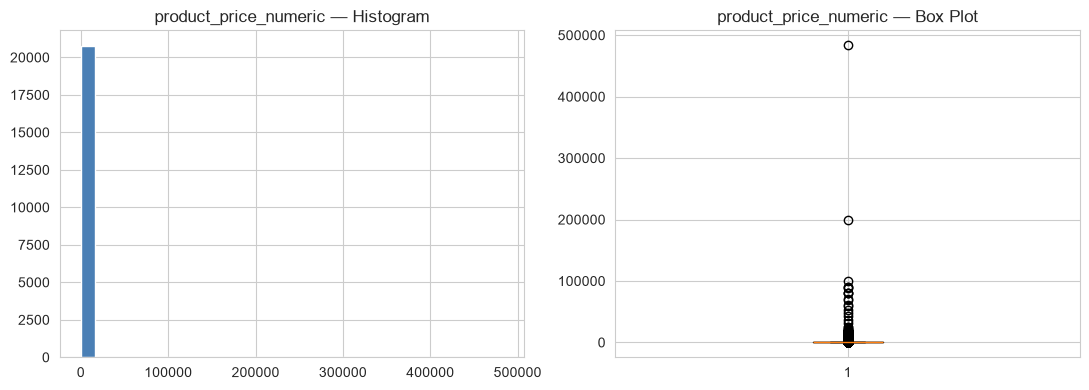

In [20]:
col = "product_price_numeric"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `product_currency`

In [21]:
col = "product_currency"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_currency: 20633 non-null / 20820 (0.9% missing)
Populated by source:
source
CustomLinc       24
Fareharbor    11230
Ingresso         16
Rezdy          9363
Name: product_currency, dtype: int64

Unique values: 4
product_currency
AUD    15789
NZD     4828
USD       11
EUR        5
Name: count, dtype: int64

Sample values:
  AUD
  AUD
  AUD


#### `price_including_tax`

In [22]:
col = "price_including_tax"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


price_including_tax: 11230 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11230
Name: price_including_tax, dtype: int64

count     11230.000000
mean        522.195703
std        5520.009055
min           0.000000
25%          61.062500
50%         150.000000
75%         349.000000
max      556000.000000
Name: price_including_tax, dtype: float64


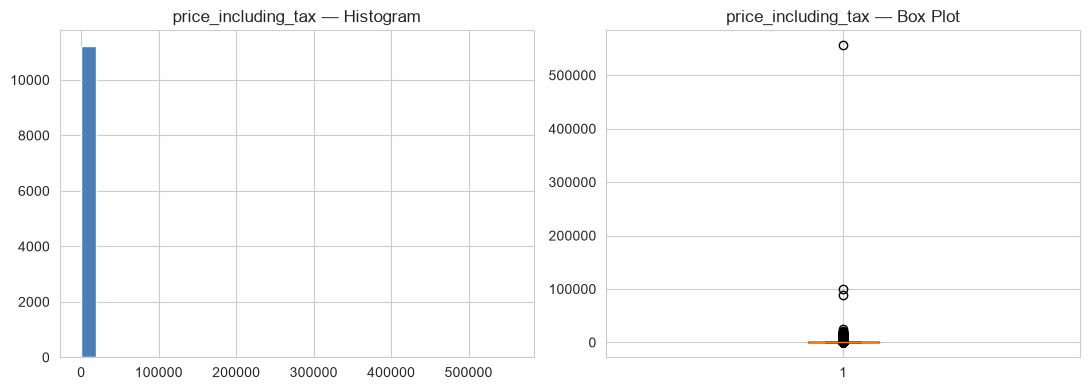

In [23]:
col = "price_including_tax"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `price_options`

In [24]:
col = "price_options"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


price_options: 9319 non-null / 20820 (55.2% missing)
Populated by source:
source
Rezdy    9319
Name: price_options, dtype: int64

Unique values: 5631
Top 10 value counts:
price_options
Quantity: $150.0                                                44
Quantity: $199.0                                                39
Quantity: $175.0                                                38
Quantity: $250.0                                                37
Adult: $89.0 | Child: $35.0 | 2 Adults + 2 Children: $213.0     37
Adult: $178.0 | Child: $70.0 | 2 Adults + 2 Children: $426.0    32
Quantity: $100.0                                                32
Quantity: $120.0                                                29
Quantity: $99.0                                                 29
Quantity: $79.0                                                 27
Name: count, dtype: int64

Sample values:
  Passenger: $69.0
  Custom: $358.0
  Adult: $250.0 | Child: $200.0


#### `price_options_summary`

In [25]:
col = "price_options_summary"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


price_options_summary: 11230 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11230
Name: price_options_summary, dtype: int64

Unique values: 8579
Top 10 value counts:
price_options_summary
Person: $136.36                                                                                                                                                                                                                                                                                                                              29
Bounce Pass - Group Rate (1 hour & 45 Mins ): $22.73 | Bounce Pass (1 hour & 45 Mins): $27.27 | Bounce Pass - Toddler + Caregiver  ( 1 hour & 45 Mins): $40.91 | Bounce & Slide ( 1 hour & 45 Mins): $36.36 | Bounce & Slide - Toddler + Caregiver ( 1 hour & 45 Mins): $54.55 | Bounce & Slide - Group rate  ( 1 hour & 45 Mins): $31.82    29
Adult: $22.73 | Child: $9.09 | Infant: $0.00                                                                    

#### `detail_tax_percentage`

In [26]:
col = "detail_tax_percentage"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


detail_tax_percentage: 11231 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11231
Name: detail_tax_percentage, dtype: int64

count    11231.000000
mean        10.489449
std          4.005456
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max        100.000000
Name: detail_tax_percentage, dtype: float64


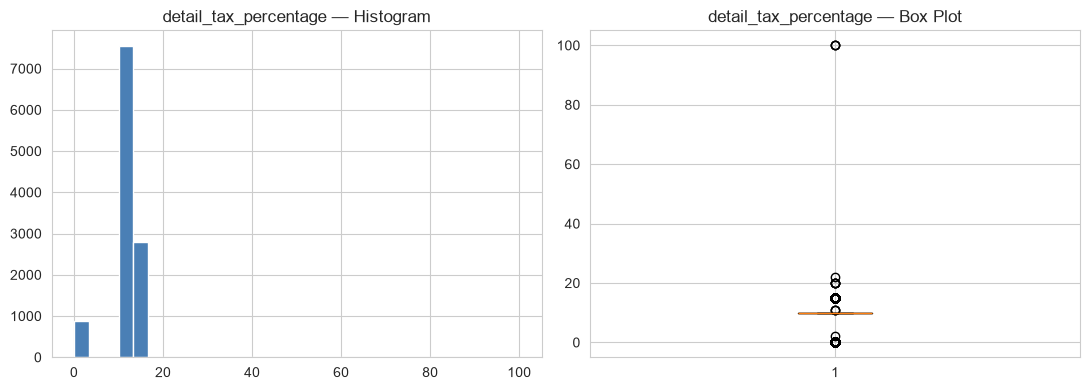

In [27]:
col = "detail_tax_percentage"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `fare_types`

In [28]:
col = "fare_types"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


fare_types: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: fare_types, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    24.000000
mean      4.166667
std       0.481543
min       4.000000
25%       4.000000
50%       4.000000
75%       4.000000
max       6.000000
dtype: float64

Sample raw values:
  [{"ageMax": 0, "ageMin": 0, "captureAge": false, "captureConcession": false, "capturePensioner": false, "captureSenior": false, "code": "ADULT", "countAsAdult": 1, "countAsChild": 0, "countAsConcessio
  [{"ageMax": 0, "ageMin": 0, "captureAge": false, "captureConcession": false, "capturePensioner": false, "captureSenior": false, "code": "ADULT", "countAsAdult": 1, "countAsChild": 0, "countAsConcessio
  [{"ageMax": 0, "ageMin": 0, "captureAge": false, "captureConcession": false, "capturePensioner": false, "captureSenior": false, "code": "ADULT", "countAsAdult": 1, "countAsChild": 0, "countAsConcessio


#### `cancellation_days`

In [29]:
col = "cancellation_days"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


cancellation_days: 7273 non-null / 20820 (65.1% missing)
Populated by source:
source
Rezdy    7273
Name: cancellation_days, dtype: int64

count    7273.000000
mean      262.226592
std      1573.187451
min         0.000000
25%         1.000000
50%         7.000000
75%         7.000000
max      9999.000000
Name: cancellation_days, dtype: float64


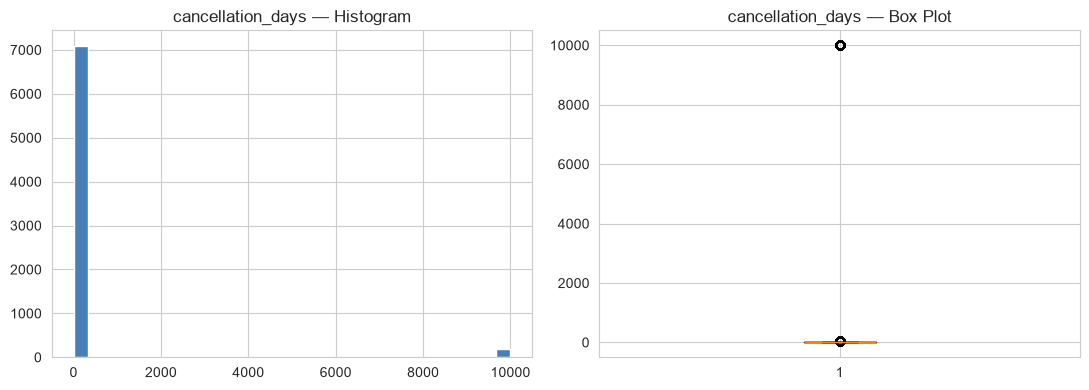

In [30]:
col = "cancellation_days"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `cancellation_hours`

In [31]:
col = "cancellation_hours"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


cancellation_hours: 11227 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11227
Name: cancellation_hours, dtype: int64

count    11227.000000
mean        24.192928
std         12.445592
min          0.000000
25%         24.000000
50%         24.000000
75%         24.000000
max        336.000000
Name: cancellation_hours, dtype: float64


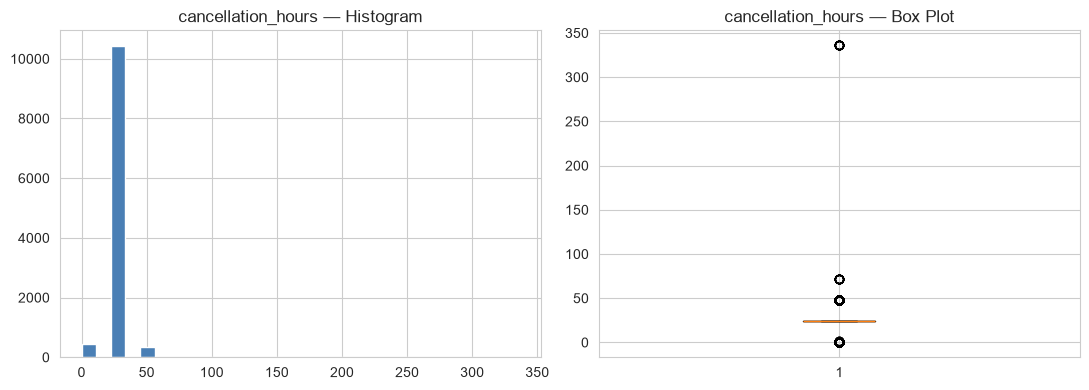

In [32]:
col = "cancellation_hours"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `cancellation_type`

In [33]:
col = "cancellation_type"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


cancellation_type: 11231 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11231
Name: cancellation_type, dtype: int64

Unique values: 2
cancellation_type
hours-before-start    11227
never                     4
Name: count, dtype: int64

Sample values:
  hours-before-start
  hours-before-start
  hours-before-start


### 2.3 Location Fields

#### `location_street`

In [34]:
col = "location_street"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_street: 15281 non-null / 20820 (26.6% missing)
Populated by source:
source
CustomLinc       2
Fareharbor    7933
Ingresso         1
Livn           116
Rezdy         7229
Name: location_street, dtype: int64

Unique values: 4367
Top 10 value counts:
location_street
41 Activity Crecent                          310
Warwick Railway Station, Brosnan Crescent    105
26 Redden Street                              88
4 Brecon Street                               87
34-40 Queen St                                54
1093 Upper Logan Rd                           53
River Valley Lodge, 266 Mangahoata Road       52
1 Bridge Road                                 49
Shop 4, 2 Christensen Road                    44
850 Mount Cotton Road                         43
Name: count, dtype: int64

Sample values:
  f3/19 Kitchener Dr
  Dock 1, Stokes Hill Wharf
  1 Captain Cook Drive, Caltex Service Station


#### `location_city`

In [35]:
col = "location_city"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_city: 16022 non-null / 20820 (23.0% missing)
Populated by source:
source
Fareharbor    8112
Ingresso        12
Livn           167
Rezdy         7712
Ventus          19
Name: location_city, dtype: int64

Unique values: 1871
Top 10 value counts:
location_city
Sydney        459
Queenstown    427
Cairns        322
Molendinar    310
Auckland      298
Melbourne     250
Pokolbin      203
Hobart        180
Adelaide      180
Rotorua       155
Name: count, dtype: int64

Sample values:
  Darwin
  Darwin
  Agnes Water


#### `location_state`

In [36]:
col = "location_state"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_state: 15088 non-null / 20820 (27.5% missing)
Populated by source:
source
Fareharbor    7844
Livn           167
Rezdy         7077
Name: location_state, dtype: int64

Unique values: 261
Top 10 value counts:
location_state
NSW                  2178
QLD                  2110
Queensland           1310
New South Wales      1036
WA                    981
VIC                   703
SA                    614
Victoria              528
Western Australia     405
South Australia       374
Name: count, dtype: int64

Sample values:
  NT
  NT
  QLD


#### `location_country`

In [37]:
col = "location_country"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_country: 16698 non-null / 20820 (19.8% missing)
Populated by source:
source
Fareharbor    8044
Ingresso        16
Livn           167
Rezdy         8471
Name: location_country, dtype: int64

Unique values: 11
location_country
AU    12673
NZ     4011
NF        4
US        3
MY        1
AT        1
ID        1
MX        1
NC        1
JP        1
TH        1
Name: count, dtype: int64

Sample values:
  AU
  AU
  AU


#### `location_postcode`

In [38]:
col = "location_postcode"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_postcode: 14727 non-null / 20820 (29.3% missing)
Populated by source:
source
Fareharbor    7780
Ingresso        16
Rezdy         6931
Name: location_postcode, dtype: int64

Unique values: 1121
Top 10 value counts:
location_postcode
2000    439
4214    312
4217    267
4870    246
9300    228
2320    200
4802    191
2095    186
7000    167
3000    167
Name: count, dtype: int64

Sample values:
  0800
  0800
  4677


#### `location_latitude`

In [39]:
col = "location_latitude"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


location_latitude: 16501 non-null / 20820 (20.7% missing)
Populated by source:
source
Fareharbor    6980
Ingresso        16
Livn           167
Rezdy         9338
Name: location_latitude, dtype: int64

count    16501.000000
mean       -31.769189
std         10.459835
min        -46.931832
25%        -37.862666
50%        -33.863965
75%        -27.877499
max         51.849501
Name: location_latitude, dtype: float64


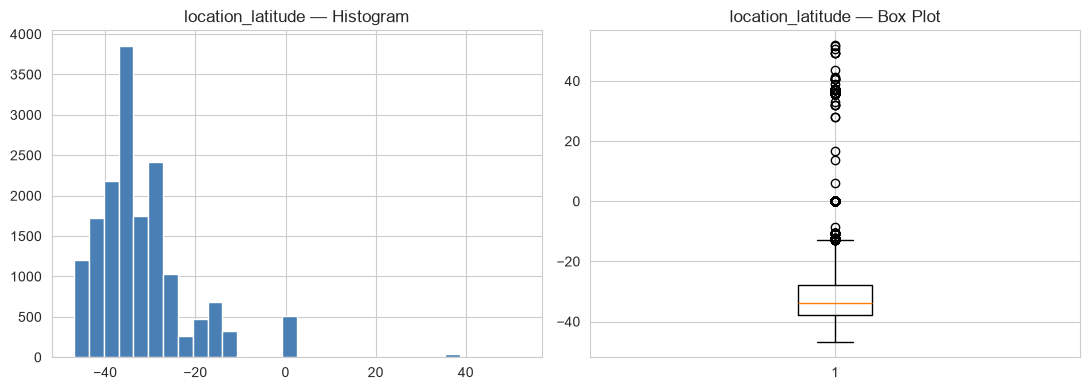

In [40]:
col = "location_latitude"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `location_longitude`

In [41]:
col = "location_longitude"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


location_longitude: 16501 non-null / 20820 (20.7% missing)
Populated by source:
source
Fareharbor    6980
Ingresso        16
Livn           167
Rezdy         9338
Name: location_longitude, dtype: int64

count    16501.000000
mean       145.612950
std         32.508893
min       -123.338046
25%        144.127906
50%        151.202045
75%        153.520844
max        178.318659
Name: location_longitude, dtype: float64


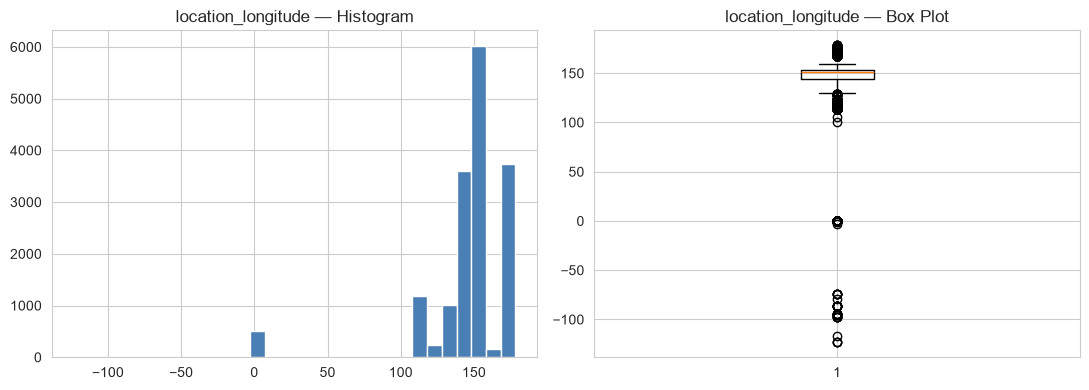

In [42]:
col = "location_longitude"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `location_id`

In [43]:
col = "location_id"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


location_id: 19 non-null / 20820 (99.9% missing)
Populated by source:
source
Ventus    19
Name: location_id, dtype: int64

count    19.000000
mean      4.368421
std       3.022334
min       1.000000
25%       2.000000
50%       4.000000
75%       5.500000
max      10.000000
Name: location_id, dtype: float64


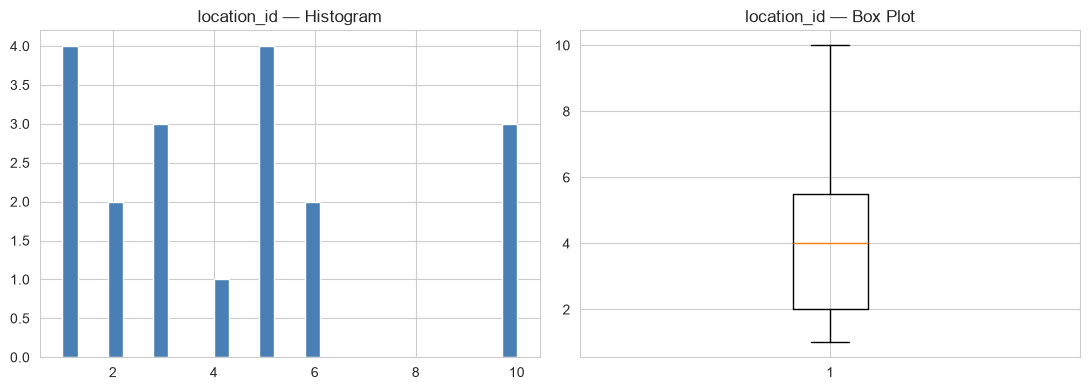

In [44]:
col = "location_id"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `location_source`

In [45]:
col = "location_source"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_source: 167 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    167
Name: location_source, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    167.000000
mean       1.029940
std        0.230901
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64

Sample raw values:
  [{"latitude": -27.997215421294463, "longitude": 153.429399049735, "tz": "Australia/Brisbane", "continent": "OC", "city": "Gold Coast", "district": "Surfers Paradise", "state": "QLD", "country": "AU", 
  [{"latitude": -16.92461, "longitude": 145.77784, "tz": "Australia/Brisbane", "continent": "OC", "city": "Cairns", "district": "Cairns City", "state": "QLD", "country": "AU", "streetAddressAccuracy": f
  [{"latitude": -16.92461, "longitude": 145.77784, "tz": "Australia/Brisbane", "continent": "OC", "city": "Cairns", "district": "Cairns City", "state": "QLD", "country": "AU", "streetAddressAccuracy": f


#### `location_end_source`

In [46]:
col = "location_end_source"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


location_end_source: 167 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    167
Name: location_end_source, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    167.000000
mean       1.029940
std        0.230901
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64

Sample raw values:
  [{"latitude": -27.997215421294463, "longitude": 153.429399049735, "tz": "Australia/Brisbane", "continent": "OC", "city": "Gold Coast", "district": "Surfers Paradise", "state": "QLD", "country": "AU", 
  [{"latitude": -16.92461, "longitude": 145.77784, "tz": "Australia/Brisbane", "continent": "OC", "city": "Cairns", "district": "Cairns City", "state": "QLD", "country": "AU", "streetAddressAccuracy": f
  [{"latitude": -16.92461, "longitude": 145.77784, "tz": "Australia/Brisbane", "continent": "OC", "city": "Cairns", "district": "Cairns City", "state": "QLD", "country": "AU", "streetAddressAccurac

#### `venue_name`

In [47]:
col = "venue_name"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


venue_name: 16 non-null / 20820 (99.9% missing)
Populated by source:
source
Ingresso    16
Name: venue_name, dtype: int64

Unique values: 12
venue_name
Passport Miscellaneous Venue                                  3
Dreamworld Pkwy, Coomera QLD 4209, Australia                  2
1-5 Wheat Rd, Sydney NSW 2000, Australia                      2
Madame Tussauds Sydney                                        1
SEA LIFE Sunshine Coast                                       1
SEA LIFE Melbourne                                            1
Sea Life Kelly Tarlton's Auckland                             1
Skypoint                                                      1
Dreamworld\r\nDreamworld Pkwy, Coomera QLD 4209, Australia    1
Wild Life Sydney                                              1
Dreamworld                                                    1
WILD Adventures                                               1
Name: count, dtype: int64

Sample values:
  Madame Tussauds Sydney
  SEA LIFE Su

#### `meeting_point_notes`

In [48]:
col = "meeting_point_notes"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meeting_point_notes: 13 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    13
Name: meeting_point_notes, dtype: int64

Unique values: 5
meeting_point_notes
Hillarys Boat Harbour                                       5
At 4WD Kiosk located 100m within the dunes after carpark    4
Rottnest Island Settlement Main Bus Stop                    2
Rottnest Island Settlement Railway Station                  1
Hotel and pick up time to be confirmed                      1
Name: count, dtype: int64

Sample values:
  At 4WD Kiosk located 100m within the dunes after carpark
  At 4WD Kiosk located 100m within the dunes after carpark
  At 4WD Kiosk located 100m within the dunes after carpark


### 2.4 Description & Content Fields

#### `detail_description`

In [49]:
col = "detail_description"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_description: 20534 non-null / 20820 (1.4% missing)
Populated by source:
source
Fareharbor    11072
Ingresso          3
Livn            167
Rezdy          9285
Ventus            7
Name: detail_description, dtype: int64

Unique values: 18876
Top 10 value counts:
detail_description
Purchase a fantastic gift or gifts: each gift certificate is the exact value of one of our offerings.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              35
Please visit our website for full d

#### `detail_highlights`

In [50]:
col = "detail_highlights"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_highlights: 17396 non-null / 20820 (16.4% missing)
Populated by source:
source
Fareharbor    10094
Livn            167
Rezdy          7135
Name: detail_highlights, dtype: int64

Unique values: 15352
Top 10 value counts:
detail_highlights
Enjoy a professional, efficient and stress-free one way transfer from Brisbane Airport to the city center. The most convenient way to travel between Brisbane Airport and your hotel at Brisbane's CBD. Sit back and relax as you're driven by a professional and experienced driver. With direct one-hop service to your hotel, you don't need to worry about navigating Brisbane. Book up to 24 hours in advance with an easy e-ticket, so you can travel stress-free.                                                                                                                                                                                               135
NRMA Insurance SurfGroms adopts an approach to learning that uses group-based games to not only equip yo

#### `detail_what_is_included`

In [51]:
col = "detail_what_is_included"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_what_is_included: 13334 non-null / 20820 (36.0% missing)
Populated by source:
source
Fareharbor    7275
Livn           167
Rezdy         5892
Name: detail_what_is_included, dtype: int64

Unique values: 11117
Top 10 value counts:
detail_what_is_included
Surfboard\nWetsuit\nRash Shirt\nSunscreen\nExperienced and accredited Surfing Australia instructors                                             75
Ice skates rentals, which are included FREE in your registration.                                                                               40
everything is provided                                                                                                                          27
full face helmet, knee pads and elbow pads                                                                                                      18
Includes a three month membership to the Australian Parachute Federation. Includes a personalised certificate of achievement.                   16
Frien

#### `detail_what_is_not_included`

In [52]:
col = "detail_what_is_not_included"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_what_is_not_included: 6147 non-null / 20820 (70.5% missing)
Populated by source:
source
Fareharbor    3264
Livn             9
Rezdy         2874
Name: detail_what_is_not_included, dtype: int64

Unique values: 4493
Top 10 value counts:
detail_what_is_not_included
,                                                                                                                                                                                                                                                                                          93
Lunch                                                                                                                                                                                                                                                                                      22
Km limit = 500 km per day (additional fees apply for additional kms).\nPetrol = full on pick-up, full on return (if not filled on return – pump price plus adm

#### `detail_itinerary`

In [53]:
col = "detail_itinerary"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_itinerary: 4720 non-null / 20820 (77.3% missing)
Populated by source:
source
Fareharbor    3476
Livn           167
Rezdy         1077
Name: detail_itinerary, dtype: int64

Unique values: 4214
Top 10 value counts:
detail_itinerary
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

#### `detail_what_to_bring`

In [54]:
col = "detail_what_to_bring"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_what_to_bring: 7751 non-null / 20820 (62.8% missing)
Populated by source:
source
Fareharbor    5793
Livn           138
Rezdy         1820
Name: detail_what_to_bring, dtype: int64

Unique values: 5040
Top 10 value counts:
detail_what_to_bring
Swimwear\nTowel\nSunscreen\nDrinking water\nA HUGE smile and readiness to have lots of fun !!                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            70
camera                                                             

#### `detail_booking_notes`

In [55]:
col = "detail_booking_notes"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_booking_notes: 13259 non-null / 20820 (36.3% missing)
Populated by source:
source
Fareharbor    9042
Ingresso        16
Livn           167
Rezdy         4034
Name: detail_booking_notes, dtype: int64

Unique values: 9624
Top 10 value counts:
detail_booking_notes
Please arrive at the Railway Station at least 30 minutes before departure to allow for check-in and boarding.\nBYO alcohol is not permitted on the train. A variety of alcoholic beverages can be purchased from our onboard cafe.                                                                                                                                                                                                                                                97
Looking forward to seeing you!                                                                                                                                                                                                                                        

#### `detail_cancellation_policy`

In [56]:
col = "detail_cancellation_policy"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_cancellation_policy: 15013 non-null / 20820 (27.9% missing)


Populated by source:


source
Fareharbor    11044
Rezdy          3962
Ventus            7
Name: detail_cancellation_policy, dtype: int64

Unique values: 4855
Top 10 value counts:
detail_cancellation_policy
Customers will receive a full refund or credit with 24 hours notice of cancellation. Customers will also receive a full refund or credit in case of operator cancellation due to weather or other unforeseen circumstances. Contact us by phone to cancel or inquire about a cancellation. No-shows will be charged the full price.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

#### `detail_health_safety`

In [57]:
col = "detail_health_safety"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_health_safety: 851 non-null / 20820 (95.9% missing)


Populated by source:
source
Fareharbor    832
Ventus         19
Name: detail_health_safety, dtype: int64

Unique values: 415
Top 10 value counts:
detail_health_safety
Before making your booking, please read the following carefully:\n1. Assumption of Risk: I, we understand and acknowledge that participating in activities aboard the charter boat involves \ninherent risks, including but not limited to those associated with water activities, weather conditions, and marine life \nencounters. I, we, voluntarily assume all risks associated with participation and agree that Big Mama Sailing, its owners, \nemployees, and affiliates shall not be held liable for any injuries, damages, or losses that may occur as a result of my \nparticipation. \n2. Physical Health and Abilities: I, we, certify that are physically fit and able to participate in the activities offered aboard \nthe charter boat. I, we understand that it is our responsibility to inform the crew of any medical conditions, disabilitie

#### `detail_accessibility`

In [58]:
col = "detail_accessibility"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_accessibility: 2427 non-null / 20820 (88.3% missing)
Populated by source:
source
Rezdy    2427
Name: detail_accessibility, dtype: int64

Unique values: 55
Top 10 value counts:
detail_accessibility
Asthmatic | Vision Impaired | Epileptic | Hearing Impaired                                449
Paraplegic | Asthmatic | Quadriplegic | Vision Impaired | Epileptic | Hearing Impaired    349
Hearing Impaired                                                                          186
Vision Impaired | Hearing Impaired | Paraplegic | Asthmatic | Quadriplegic | Epileptic    177
Asthmatic | Vision Impaired | Hearing Impaired                                            162
Asthmatic                                                                                 159
Asthmatic | Epileptic | Hearing Impaired                                                  146
Vision Impaired | Hearing Impaired                                                        144
Asthmatic | Hearing Impaired                

#### `detail_min_age`

In [59]:
col = "detail_min_age"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


detail_min_age: 33 non-null / 20820 (99.8% missing)
Populated by source:
source
Livn    33
Name: detail_min_age, dtype: int64

count    33.000000
mean     10.090909
std       4.830655
min       1.000000
25%       4.000000
50%      12.000000
75%      15.000000
max      18.000000
Name: detail_min_age, dtype: float64


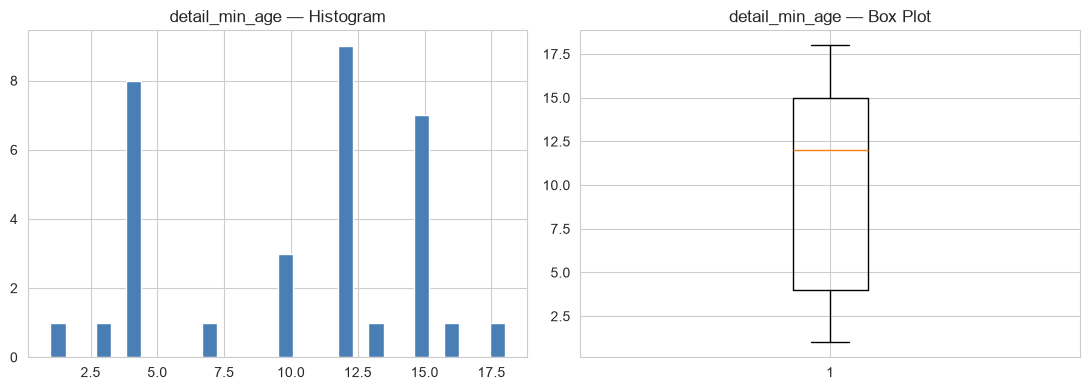

In [60]:
col = "detail_min_age"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `detail_group_size`

In [61]:
col = "detail_group_size"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


detail_group_size: 7 non-null / 20820 (100.0% missing)


Populated by source:
source
Livn    7
Name: detail_group_size, dtype: int64

count      7.000000
mean      47.428571
std       60.681840
min        8.000000
25%       20.000000
50%       20.000000
75%       42.000000
max      180.000000
Name: detail_group_size, dtype: float64


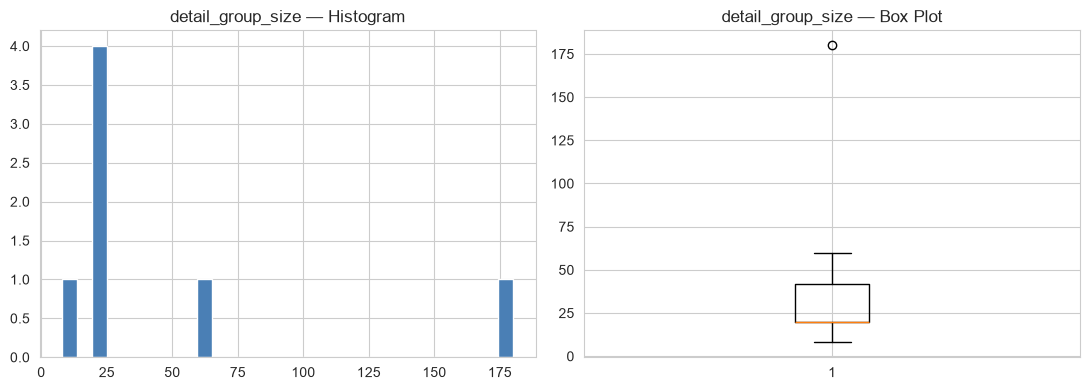

In [62]:
col = "detail_group_size"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `non_flight_inclusions`

In [63]:
col = "non_flight_inclusions"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


non_flight_inclusions: 19 non-null / 20820 (99.9% missing)


Populated by source:
source
Ventus    19
Name: non_flight_inclusions, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    19.000000
mean      1.736842
std       0.991189
min       1.000000
25%       1.000000
50%       1.000000
75%       3.000000
max       3.000000
dtype: float64

Sample raw values:
  [{"non_flight_items_id": {"id": 7, "name": "Digital Photo Album"}, "pax": false}]
  [{"non_flight_items_id": {"id": 7, "name": "Digital Photo Album"}, "pax": false}]
  [{"non_flight_items_id": {"id": 7, "name": "Digital Photo Album"}, "pax": false}]


#### `breakfast_details`

In [64]:
col = "breakfast_details"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


breakfast_details: 15 non-null / 20820 (99.9% missing)
Populated by source:
source
Ventus    15
Name: breakfast_details, dtype: int64

Unique values: 8
breakfast_details
Celebration Breakfast @ Three Blue Ducks, The Farm Byron Bay    3
Buffet Breakfast                                                3
Bubbly Breakfast at Restaurant Cuvee                            2
Celebration Breakfast @ Gigi's Restaurant                       2
Celebration Breakfast @ Camden Valley Inn                       2
Bubbly Breakfast at Restaurant Cuvee, Peterson House            1
Bubbly Breakfast at Restaurant Cuvee, Peterson House.           1
Celebration Breakfast at Camden Valley Inn                      1
Name: count, dtype: int64

Sample values:
  Bubbly Breakfast at Restaurant Cuvee
  Bubbly Breakfast at Restaurant Cuvee, Peterson House
  Bubbly Breakfast at Restaurant Cuvee, Peterson House.


#### `has_breakfast_included`

In [65]:
col = "has_breakfast_included"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


has_breakfast_included: 19 non-null / 20820 (99.9% missing)
Populated by source:
source
Ventus    19
Name: has_breakfast_included, dtype: int64

Unique values: 2
has_breakfast_included
True     15
False     4
Name: count, dtype: int64

Sample values:
  True
  True
  True


### 2.5 Images & Media

#### `product_images`

In [66]:
col = "product_images"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_images: 20318 non-null / 20820 (2.4% missing)
Populated by source:
source
Fareharbor    11231
Livn            166
Rezdy          8902
Ventus           19
Name: product_images, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    3000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64

Sample raw values:
  https://img.rezdy.com/PRODUCT_IMAGE/185297/1e5793fb651f42d2961658b2e6b36f9fPhoto_13_9_21__6_43_01_pm_lg.jpg | https://img.rezdy.com/PRODUCT_IMAGE/185297/photo_4_lg.jpg | https://img.rezdy.com/PRODUCT_
  https://img.rezdy.com/PRODUCT_IMAGE/185297/Untitled_design__14__lg.png | https://img.rezdy.com/PRODUCT_IMAGE/185297/Untitled_design__6__lg.png | https://img.rezdy.com/PRODUCT_IMAGE/185297/Photo_29_4_2
  https://img.rezdy.com/PRODUCT_IMAGE/60630/Survivor__20__lg.jpg | https://img.rezdy.com/PRODUCT_IMAGE/60630/5b2b443995c34df0af3c4214214518a514199366_1403285499700830_435

#### `product_main_image`

In [67]:
col = "product_main_image"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


product_main_image: 19848 non-null / 20820 (4.7% missing)
Populated by source:
source
Fareharbor    10946
Rezdy          8902
Name: product_main_image, dtype: int64

Unique values: 18893
Top 10 value counts:
product_main_image
https://img.rezdy.com/PRODUCT_IMAGE/228957/sawyersbay_web_525_lg.jpg                                                 18
https://img.rezdy.com/PRODUCT_IMAGE/7434/d658f97fe2ea42af9694ca8938580e17ATDW2_111028-53650Kuranda_Markets_lg.jpg    14
https://img.rezdy.com/PRODUCT_IMAGE/7434/Kuranda_Scenic_Rail_lg.jpg                                                  14
https://img.rezdy.com/PRODUCT_IMAGE/21721/2ec33e794e5242dab61c570e00411026R_tb_lg.jpg                                 9
https://img.rezdy.com/PRODUCT_IMAGE/7747/8ae31d1486864cef801cea4da43fa811goodoceanfloordivewithreef_tb.jpg            8
https://img.rezdy.com/PRODUCT_IMAGE/203084/Whisky_Bar_2.jpg_lg.png                                                    7
https://img.rezdy.com/PRODUCT_IMAGE/198445/6efe577e6e

#### `image_count`

In [68]:
col = "image_count"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


image_count: 20594 non-null / 20820 (1.1% missing)
Populated by source:
source
Fareharbor    11231
Rezdy          9363
Name: image_count, dtype: int64

count    20594.000000
mean         4.900554
std          6.653141
min          0.000000
25%          1.000000
50%          3.000000
75%          7.000000
max        267.000000
Name: image_count, dtype: float64


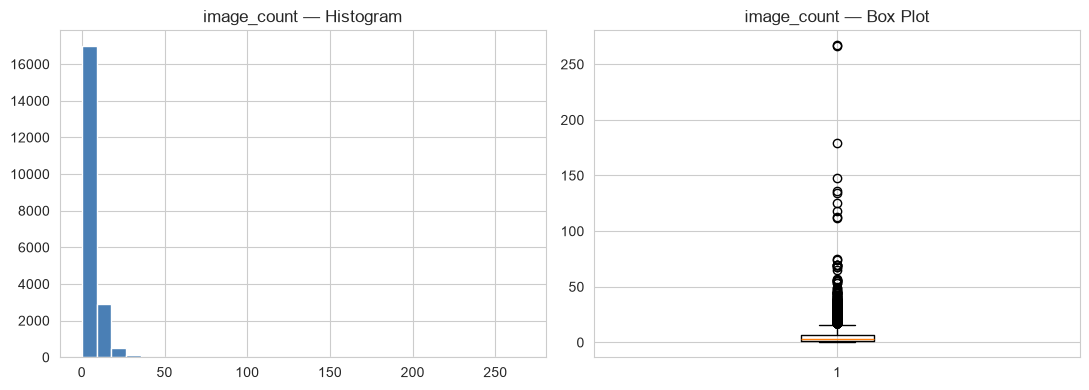

In [69]:
col = "image_count"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


### 2.6 Booking, Scheduling & Logistics Fields

#### `product_duration`

In [70]:
col = "product_duration"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


product_duration: 12254 non-null / 20820 (41.1% missing)
Populated by source:
source
CustomLinc      24
Fareharbor    3228
Livn           167
Rezdy         8835
Name: product_duration, dtype: int64

count     12254.000000
mean       1085.027746
std        3783.774297
min           0.000000
25%         120.000000
50%         240.000000
75%         480.000000
max      129600.000000
Name: product_duration, dtype: float64


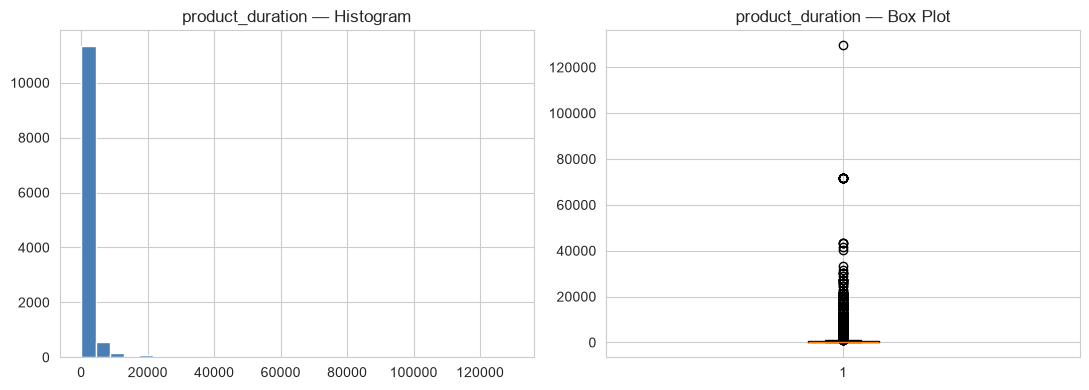

In [71]:
col = "product_duration"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `product_duration_range_max`

In [72]:
col = "product_duration_range_max"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


product_duration_range_max: 26 non-null / 20820 (99.9% missing)
Populated by source:
source
Livn    26
Name: product_duration_range_max, dtype: int64

count       26.000000
mean      1540.384615
std       3046.478269
min        360.000000
25%        360.000000
50%        360.000000
75%        495.000000
max      11520.000000
Name: product_duration_range_max, dtype: float64


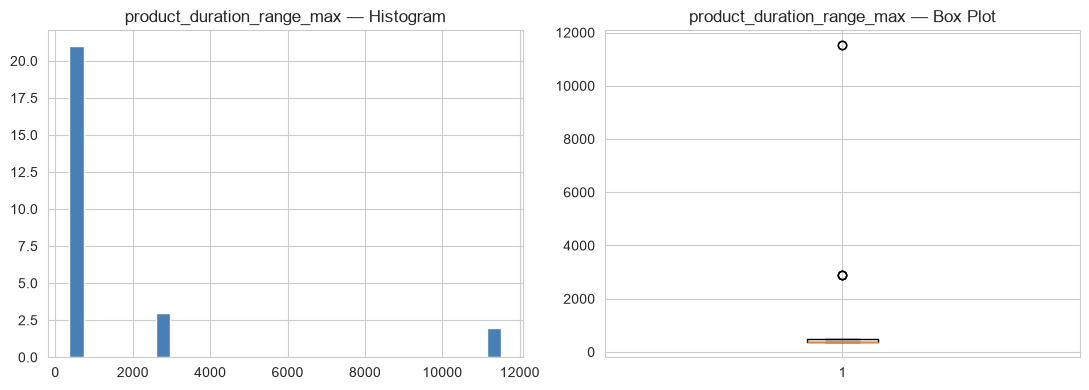

In [73]:
col = "product_duration_range_max"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `duration_display`

In [74]:
col = "duration_display"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


duration_display: 8760 non-null / 20820 (57.9% missing)
Populated by source:
source
CustomLinc      24
Rezdy         8736
Name: duration_display, dtype: int64

Unique values: 145
Top 10 value counts:
duration_display
2 hrs      815
4 hrs      813
3 hrs      798
8 hrs      664
1 hrs      557
6 hrs      427
1.5 hrs    405
7 hrs      385
5 hrs      379
10 hrs     265
Name: count, dtype: int64

Sample values:
  1 hrs
  1.5 hrs
  2 days


#### `duration_text`

In [75]:
col = "duration_text"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


duration_text: 5129 non-null / 20820 (75.4% missing)
Populated by source:
source
Fareharbor    5129
Name: duration_text, dtype: int64

Unique values: 1499
Top 10 value counts:
duration_text
2 hours      169
2 Hours      162
3 Hours      141
1 Hour       134
8 Hours      105
1.5 Hours     98
1.5 hours     97
1 hour        95
3 hours       94
2.5 Hours     83
Name: count, dtype: int64

Sample values:
  2 Hours for each activity
  3.5 hours
  2 hours Sandboarding and an All Day pass for Oakvale


#### `duration_unit_source`

In [76]:
col = "duration_unit_source"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


duration_unit_source: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: duration_unit_source, dtype: int64

Unique values: 2
duration_unit_source
HH:MM    13
days     11
Name: count, dtype: int64

Sample values:
  days
  days
  days


#### `detail_operating_days`

In [77]:
col = "detail_operating_days"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_operating_days: 171 non-null / 20820 (99.2% missing)
Populated by source:
source
CustomLinc      4
Livn          167
Name: detail_operating_days, dtype: int64

Unique values: 12
detail_operating_days
Mon,Tue,Wed,Thu,Fri,Sat,Sun    149
Mon,Wed,Thu,Fri,Sat,Sun          6
Mon,Tue,Wed,Thu,Fri,Sat          4
Daily                            4
Mon,Tue,Wed,Fri,Sat,Sun          1
Mon,Tue,Thu                      1
Mon,Wed                          1
Mon                              1
Tue,Wed,Thu,Fri,Sat              1
Fri                              1
Tue,Thu,Sat                      1
Mon,Tue,Wed,Thu,Fri              1
Name: count, dtype: int64

Sample values:
  Mon,Tue,Wed,Thu,Fri,Sat,Sun
  Mon,Tue,Wed,Fri,Sat,Sun
  Mon,Tue,Wed,Thu,Fri,Sat,Sun


#### `detail_start_time`

In [78]:
col = "detail_start_time"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_start_time: 163 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    163
Name: detail_start_time, dtype: int64

Unique values: 27
detail_start_time
08:30:00    48
09:00:00    28
08:00:00    23
10:00:00    10
10:15:00    10
10:30:00     6
11:00:00     5
10:45:00     4
05:45:00     3
07:00:00     3
06:00:00     3
07:30:00     2
09:15:00     2
11:30:00     2
08:45:00     2
10:10:00     1
15:25:00     1
08:40:00     1
09:45:00     1
12:00:00     1
13:00:00     1
17:45:00     1
07:45:00     1
14:00:00     1
17:40:00     1
07:20:00     1
13:15:00     1
Name: count, dtype: int64

Sample values:
  05:45:00
  07:30:00
  09:00:00


#### `detail_start_time_range_max`

In [79]:
col = "detail_start_time_range_max"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


detail_start_time_range_max: 42 non-null / 20820 (99.8% missing)
Populated by source:
source
Livn    42
Name: detail_start_time_range_max, dtype: int64

Unique values: 11
detail_start_time_range_max
10:30:00    15
10:45:00     7
13:00:00     5
12:30:00     3
16:00:00     3
15:00:00     2
14:00:00     2
13:30:00     2
07:30:00     1
14:30:00     1
12:00:00     1
Name: count, dtype: int64

Sample values:
  07:30:00
  14:30:00
  12:30:00


#### `departure_date`

In [80]:
col = "departure_date"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


departure_date: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: departure_date, dtype: int64

Unique values: 1
departure_date
2026-07-13    24
Name: count, dtype: int64

Sample values:
  2026-07-13
  2026-07-13
  2026-07-13


#### `departure_time_display`

In [81]:
col = "departure_time_display"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


departure_time_display: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: departure_time_display, dtype: int64

Unique values: 12
departure_time_display
10:00 AM    7
11:00 AM    2
1:00 PM     2
2:00 PM     2
3:00 PM     2
12:01 AM    2
8:00 AM     2
11:15 AM    1
1:45 PM     1
11:30 AM    1
9:00 AM     1
12:00 PM    1
Name: count, dtype: int64

Sample values:
  10:00 AM
  11:00 AM
  1:00 PM


#### `return_time`

In [82]:
col = "return_time"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


return_time: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: return_time, dtype: int64

Unique values: 11
return_time
5:00 PM     9
4:30 PM     4
3:45 PM     2
12:01 AM    2
10:45 AM    1
11:45 AM    1
1:45 PM     1
2:45 PM     1
1:00 PM     1
3:30 PM     1
5:15 PM     1
Name: count, dtype: int64

Sample values:
  10:45 AM
  11:45 AM
  1:45 PM


#### `validity_start`

In [83]:
col = "validity_start"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


validity_start: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: validity_start, dtype: int64

Unique values: 2
validity_start
Departing     15
Visit Date     9
Name: count, dtype: int64

Sample values:
  Departing
  Departing
  Departing


#### `validity_end`

In [84]:
col = "validity_end"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


validity_end: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: validity_end, dtype: int64

Unique values: 2
validity_end
Returning    15
End Date      9
Name: count, dtype: int64

Sample values:
  Returning
  Returning
  Returning


#### `availability`

In [85]:
col = "availability"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


availability: 19 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    19
Name: availability, dtype: int64

count       19.000000
mean     16125.263158
std      37316.698977
min          0.000000
25%          0.000000
50%         39.000000
75%       1126.500000
max      99999.000000
Name: availability, dtype: float64


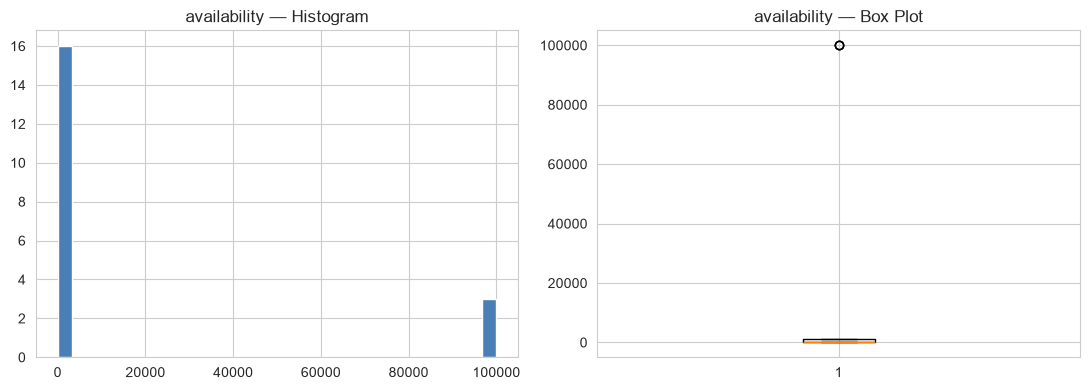

In [86]:
col = "availability"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `booking_lead_time`

In [87]:
col = "booking_lead_time"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


booking_lead_time: 15 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    15
Name: booking_lead_time, dtype: int64

count    15.000000
mean     14.300000
std      16.037679
min       0.000000
25%       1.750000
50%       6.000000
75%      36.000000
max      36.000000
Name: booking_lead_time, dtype: float64


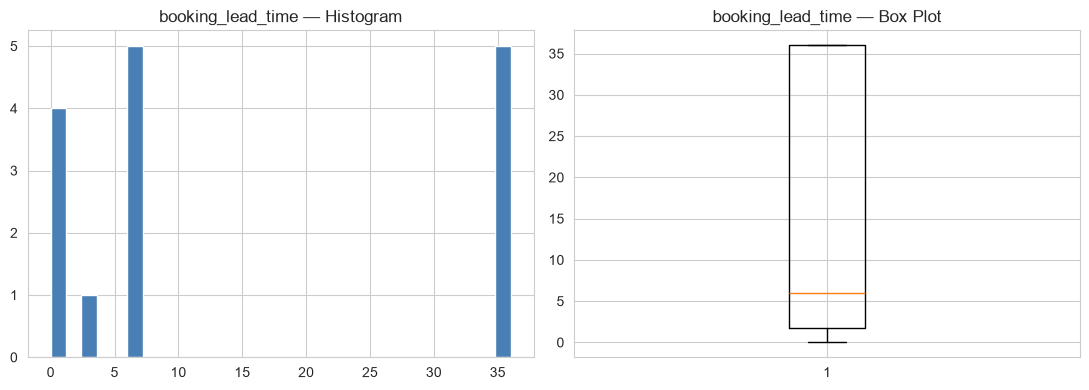

In [88]:
col = "booking_lead_time"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `is_pickup_available`

In [89]:
col = "is_pickup_available"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


is_pickup_available: 11231 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11231
Name: is_pickup_available, dtype: int64

Unique values: 2
is_pickup_available
False    10972
True       259
Name: count, dtype: int64

Sample values:
  False
  False
  False


#### `is_pickup_compulsory`

In [90]:
col = "is_pickup_compulsory"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


is_pickup_compulsory: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: is_pickup_compulsory, dtype: int64

Unique values: 2
is_pickup_compulsory
False    16
True      8
Name: count, dtype: int64

Sample values:
  False
  False
  False


#### `has_transfer_included`

In [91]:
col = "has_transfer_included"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


has_transfer_included: 19 non-null / 20820 (99.9% missing)
Populated by source:
source
Ventus    19
Name: has_transfer_included, dtype: int64

Unique values: 2
has_transfer_included
False    14
True      5
Name: count, dtype: int64

Sample values:
  True
  False
  False


#### `transfer_id`

In [92]:
col = "transfer_id"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


transfer_id: 5 non-null / 20820 (100.0% missing)
Populated by source:
source
Ventus    5
Name: transfer_id, dtype: int64

count     5.00000
mean     18.20000
std       4.38178
min      12.00000
25%      17.00000
50%      18.00000
75%      20.00000
max      24.00000
Name: transfer_id, dtype: float64


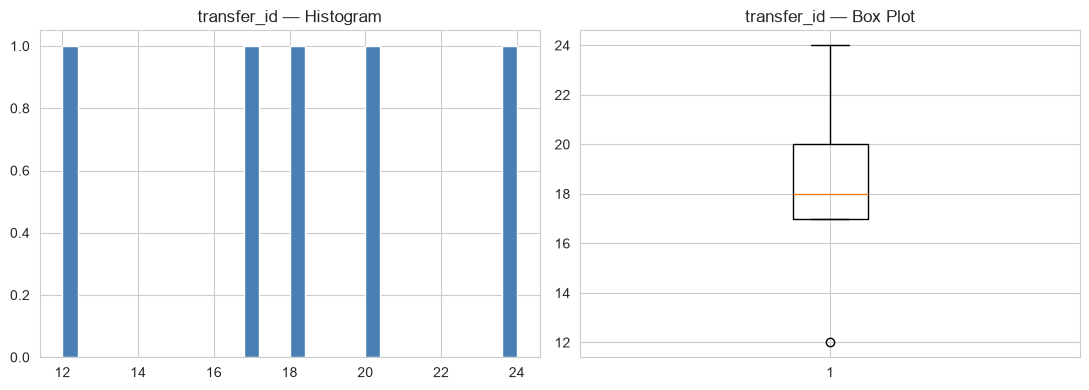

In [93]:
col = "transfer_id"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


#### `transfer_name`

In [94]:
col = "transfer_name"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


transfer_name: 5 non-null / 20820 (100.0% missing)
Populated by source:
source
Ventus    5
Name: transfer_name, dtype: int64

Unique values: 5
transfer_name
Return Transfers - Local Hunter Valley                                                      1
Return Transfers - Sydney to Hunter Valley                                                  1
Return Transfers - Sydney City to Camden                                                    1
Return Transfers - Local Byron Bay                                                          1
Return Transfer – pick up from Pullman East Melbourne (192 Wellington Parade, Melbourne)    1
Name: count, dtype: int64

Sample values:
  Return Transfers - Local Hunter Valley
  Return Transfers - Sydney to Hunter Valley
  Return Transfers - Sydney City to Camden


#### `transfer_pickup_hotels`

In [95]:
col = "transfer_pickup_hotels"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


transfer_pickup_hotels: 5 non-null / 20820 (100.0% missing)
Populated by source:
source
Ventus    5
Name: transfer_pickup_hotels, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count     5.000000
mean     38.200000
std      34.433995
min       1.000000
25%       3.000000
50%      50.000000
75%      60.000000
max      77.000000
dtype: float64

Sample raw values:
  [{"attributes_id": {"name": "Hunter Valley Resort", "phone": "(02) 4998 7777", "address": "Hermitage Rd &, Mistletoe Ln, Pokolbin NSW 2320, Australia", "id": 3}}, {"attributes_id": {"name": "Rydges Hu
  [{"attributes_id": {"name": "Furama Darling Harbour (previously Holiday Inn) ", "phone": null, "address": "68 Harbour St, Haymarket NSW 2000, Australia", "id": 204}}, {"attributes_id": {"name": "Rydge
  [{"attributes_id": {"name": "Capella Sydney", "phone": "02 90715000", "address": "24 Loftus St, Sydney NSW 2000, Australia", "id": 209}}, {"attributes_id": {"name": "Capitol Square Hotel", "phone": 

#### `pickup_locations_general`

In [96]:
col = "pickup_locations_general"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


pickup_locations_general: 8 non-null / 20820 (100.0% missing)
Populated by source:
source
CustomLinc    8
Name: pickup_locations_general, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count     8.00000
mean     46.00000
std      37.26354
min       1.00000
25%       1.00000
50%      73.00000
75%      73.00000
max      73.00000
dtype: float64

Sample raw values:
  [{"code": "ROTT01", "description": "Rottnest Island Settlement Main Bus Stop", "id": 1229, "isActive": true, "isDropoff": false, "locationType": "", "locationTypeCode": "", "mapLatitude": -31.99674906
  [{"code": "ROTT01", "description": "Rottnest Island Settlement Main Bus Stop", "id": 1229, "isActive": true, "isDropoff": false, "locationType": "", "locationTypeCode": "", "mapLatitude": -31.99674906
  [{"code": "ROTT02", "description": "Rottnest Island Settlement Railway Station", "id": 1226, "isActive": true, "isDropoff": false, "locationType": "", "locationTypeCode": "", "mapLatitude": -31.9995

#### `package_groups`

In [97]:
col = "package_groups"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


package_groups: 4 non-null / 20820 (100.0% missing)
Populated by source:
source
CustomLinc    4
Name: package_groups, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    4.0
mean     2.0
std      0.0
min      2.0
25%      2.0
50%      2.0
75%      2.0
max      2.0
dtype: float64

Sample raw values:
  [{"areDefaultDaysFixed": true, "displayOrder": 1, "enforce": true, "maxEvents": 1, "name": "Hillarys to Rottnest Return", "packageItems": null, "promptNoDate": "", "promptNoEvents": "", "promptWithDat
  [{"areDefaultDaysFixed": true, "displayOrder": 1, "enforce": true, "maxEvents": 1, "name": "Hillarys to Rottnest Return", "packageItems": null, "promptNoDate": "", "promptNoEvents": "", "promptWithDat
  [{"areDefaultDaysFixed": true, "displayOrder": 1, "enforce": false, "maxEvents": 1, "name": "Skyrail ex Smithfield", "packageItems": null, "promptNoDate": "", "promptNoEvents": "", "promptWithDate": "


#### `package_type`

In [98]:
col = "package_type"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


package_type: 4 non-null / 20820 (100.0% missing)
Populated by source:
source
CustomLinc    4
Name: package_type, dtype: int64

Unique values: 2
package_type
Undefined    2
Package      2
Name: count, dtype: int64

Sample values:
  Undefined
  Undefined
  Package


#### `is_seated`

In [99]:
col = "is_seated"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


is_seated: 16 non-null / 20820 (99.9% missing)
Populated by source:
source
Ingresso    16
Name: is_seated, dtype: int64

Unique values: 1
is_seated
False    16
Name: count, dtype: int64

Sample values:
  False
  False
  False


#### `ticket_type_details`

In [100]:
col = "ticket_type_details"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


ticket_type_details: 16 non-null / 20820 (99.9% missing)
Populated by source:
source
Ingresso    16
Name: ticket_type_details, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    16.000000
mean      2.000000
std       1.861899
min       1.000000
25%       1.000000
50%       1.000000
75%       1.750000
max       6.000000
dtype: float64

Sample raw values:
  [{"price_band": [{"avail_detail": [{"approx_last_seen_iso8601_date_and_time": "2026-07-12T05:16:52Z", "avail_currency_code": "aud", "available_dates": {"first_yyyymmdd": "20260720", "last_yyyymmdd": "
  [{"price_band": [{"avail_detail": [{"approx_last_seen_iso8601_date_and_time": "2026-07-12T04:38:17Z", "avail_currency_code": "aud", "available_dates": {"first_yyyymmdd": "20260713", "last_yyyymmdd": "
  [{"price_band": [{"avail_detail": [{"approx_last_seen_iso8601_date_and_time": "2026-07-12T04:59:19Z", "avail_currency_code": "aud", "available_dates": {"first_yyyymmdd": "20260713", "last_yyyymmdd": "


#### `valid_quantities`

In [101]:
col = "valid_quantities"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

def try_parse(v):
    try:
        parsed = json.loads(v)
        if isinstance(parsed, list):
            return parsed
    except (json.JSONDecodeError, TypeError):
        pass
    return None

lengths = []
item_samples = []
for v in nonnull.head(3000):
    parsed = try_parse(v)
    if parsed is not None:
        lengths.append(len(parsed))
        item_samples.extend(parsed[:3])
    else:
        lengths.append(1 if v.strip() else 0)

if lengths:
    print()
    print("List length distribution (sample of up to 3000 non-null rows):")
    print(pd.Series(lengths).describe())

print()
print("Sample raw values:")
for v in nonnull.head(3):
    print(" ", v[:200])


valid_quantities: 16 non-null / 20820 (99.9% missing)
Populated by source:
source
Ingresso    16
Name: valid_quantities, dtype: int64

List length distribution (sample of up to 3000 non-null rows):
count    16.0
mean     20.0
std       0.0
min      20.0
25%      20.0
50%      20.0
75%      20.0
max      20.0
dtype: float64

Sample raw values:
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


### 2.7 Metadata & Supplier Fields

#### `meta_supplier_id`

In [102]:
col = "meta_supplier_id"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meta_supplier_id: 9570 non-null / 20820 (54.0% missing)
Populated by source:
source
CustomLinc      24
Ingresso        16
Livn           167
Rezdy         9363
Name: meta_supplier_id, dtype: int64

Unique values: 1378
Top 10 value counts:
meta_supplier_id
239191    262
90077      94
28442      94
7434       90
13375      87
198445     84
142590     76
54865      71
238824     63
188824     60
Name: count, dtype: int64

Sample values:
  185297
  185297
  60630


#### `meta_supplier_name`

In [103]:
col = "meta_supplier_name"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meta_supplier_name: 9570 non-null / 20820 (54.0% missing)
Populated by source:
source
CustomLinc      24
Ingresso        16
Livn           167
Rezdy         9363
Name: meta_supplier_name, dtype: int64

Unique values: 1357
Top 10 value counts:
meta_supplier_name
Con-x-ion Airport Transfers (QLD)    262
Cheeky Kiwi Travel                    94
Eco Abrolhos Cruises Pty Ltd          94
Down Under Tours Australia            90
Vertigo Bikes                         87
WA NT Tours Pty Ltd                   84
Cheeky Kea Tours                      76
New Zealand Photography Workshops     71
Expedigo Limited                      63
Off The Beaten Track WA               60
Name: count, dtype: int64

Sample values:
  00seven Adventures
  00seven Adventures
  1770 Castaway Tours


#### `meta_supplier_email`

In [104]:
col = "meta_supplier_email"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meta_supplier_email: 167 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    167
Name: meta_supplier_email, dtype: int64

Unique values: 19
meta_supplier_email
res@greatadventures.com.au              29
daytours@tropicwings.com.au             21
book@reefunlimited.com                  21
res@sunlover.com.au                     18
res@fitzroyislandadventures.com         13
reservations@quicksilver-cruises.com    12
info@prodivecairns.com                  11
res@rainforest.com.au                   10
info@cairnsadventuregroup.com.au         9
info@wildlifehabitat.com.au              5
res@reefmagiccruises.com                 4
info@cairnskoalas.com.au                 3
res@dreamtimedive.com.au                 3
info@diversden.com.au                    2
reservations@franklandislands.com.au     2
info@sunsetsafaris.com.au                1
res@ragingthunder.com.au                 1
info@tusareeftours.com.au                1
info@spiritofcairns.com                  1
Name: 

#### `meta_supplier_phone`

In [105]:
col = "meta_supplier_phone"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meta_supplier_phone: 142 non-null / 20820 (99.3% missing)
Populated by source:
source
Livn    142
Name: meta_supplier_phone, dtype: int64

Unique values: 17
meta_supplier_phone
+61 7 4044 9944        29
+61 7 40419400         21
+61 7 4050 1333        18
+61 7 4231 9485        14
+61 7 4231 9483        13
+61 7 4031 5255        11
+61 7 4222 7465         7
+61 07 4042 7300        6
+61 7 4099 3235         5
+61 7 4046 7333         4
+61 7 4222 7479         4
+61 (07) 4031 3460      3
+61 7 4020 8200         3
+617 3287 1644          1
+61 740317460           1
+61 (0) 7 4047 9100     1
+61 7 4047 9170         1
Name: count, dtype: int64

Sample values:
  +617 3287 1644
  +61 7 40419400
  +61 7 40419400


#### `meta_supplier_website`

In [106]:
col = "meta_supplier_website"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


meta_supplier_website: 167 non-null / 20820 (99.2% missing)
Populated by source:
source
Livn    167
Name: meta_supplier_website, dtype: int64

Unique values: 20
meta_supplier_website
https://greatadventures.com.au/             29
https://tropicwings.com.au                  21
https://www.sunlover.com.au/                18
https://greenisland.com.au/                 14
https://fitzroyislandadventures.com         13
https://www.quicksilvergroup.com.au/        12
http://www.prodivecairns.com                11
https://www.rainforest.com.au               10
https://www.cairnsadventuregroup.com.au/     9
https://calypsoreefcruises.com               7
https://www.wildlifehabitat.com.au/          5
https://www.reefmagic.com.au/                4
https://cairnskoalas.com.au/                 3
https://dreamtimedive.com/                   3
http://www.diversden.com.au                  2
https://www.franklandislands.com.au          2
https://www.sunsetsafaris.com.au/            1
https://www.raging

#### `supplier_alias`

In [107]:
col = "supplier_alias"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


supplier_alias: 20594 non-null / 20820 (1.1% missing)
Populated by source:
source
Fareharbor    11231
Rezdy          9363
Name: supplier_alias, dtype: int64

Unique values: 2802
Top 10 value counts:
supplier_alias
conxionairporttransfers    262
downsexplorer              136
wayfaregroup               118
cheekykiwitravel            94
ecoabrolhos                 94
downundertours              90
vertigobikes                87
want-tours                  84
cheekykeatours              76
experiencekart              74
Name: count, dtype: int64

Sample values:
  00seven
  00seven
  1770castawaysurvivor


#### `operator_code`

In [108]:
col = "operator_code"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


operator_code: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: operator_code, dtype: int64

Unique values: 5
operator_code
69001           9
LANCELIN 4X4    5
PTG             5
ADAMSROTT       3
SKYUP           2
Name: count, dtype: int64

Sample values:
  LANCELIN 4X4
  LANCELIN 4X4
  LANCELIN 4X4


#### `booking_channel_code`

In [109]:
col = "booking_channel_code"
nonnull = df[col].dropna().astype(str)
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])

n_unique = nonnull.nunique()
print(f"\nUnique values: {n_unique}")
if n_unique <= 30:
    print(nonnull.value_counts())
else:
    print("Top 10 value counts:")
    print(nonnull.value_counts().head(10))

print()
print("Sample values:")
for v in nonnull.head(3):
    print(" ", v[:200])


booking_channel_code: 24 non-null / 20820 (99.9% missing)
Populated by source:
source
CustomLinc    24
Name: booking_channel_code, dtype: int64

Unique values: 5
booking_channel_code
SZOO-ITO     9
LANCELIN     5
RETAIL       5
ADAMSROTT    3
SKYAPI       2
Name: count, dtype: int64

Sample values:
  LANCELIN
  LANCELIN
  LANCELIN


#### `flight_type_id`

In [110]:
col = "flight_type_id"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


flight_type_id: 19 non-null / 20820 (99.9% missing)
Populated by source:
source
Ventus    19
Name: flight_type_id, dtype: int64

count    19.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: flight_type_id, dtype: float64


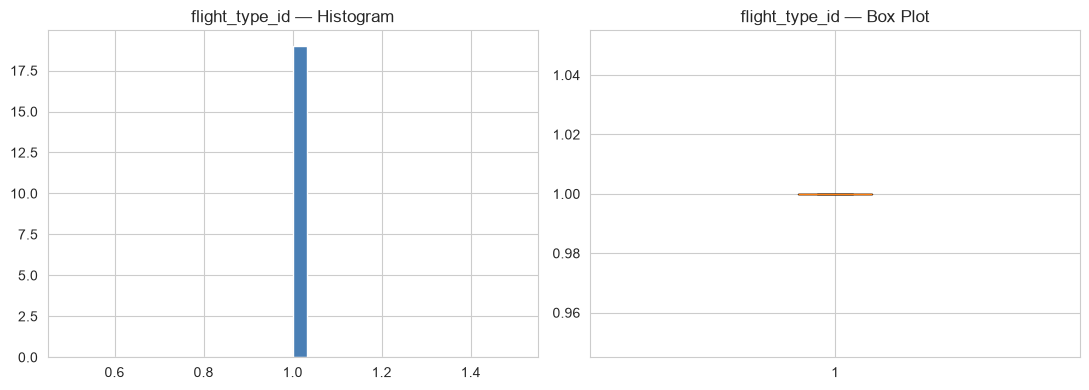

In [111]:
col = "flight_type_id"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


### 2.8 Other Fields

#### `prototype_count`

In [112]:
col = "prototype_count"
nonnull = df[col].dropna()
pct_missing = (1 - len(nonnull) / len(df)) * 100
print(f"{col}: {len(nonnull)} non-null / {len(df)} ({pct_missing:.1f}% missing)")

by_source = df.groupby('source')[col].apply(lambda s: s.notna().sum())
print("Populated by source:")
print(by_source[by_source > 0])
print()
print(nonnull.describe())


prototype_count: 11231 non-null / 20820 (46.1% missing)
Populated by source:
source
Fareharbor    11231
Name: prototype_count, dtype: int64

count    11231.000000
mean         3.376725
std          3.286025
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         39.000000
Name: prototype_count, dtype: float64


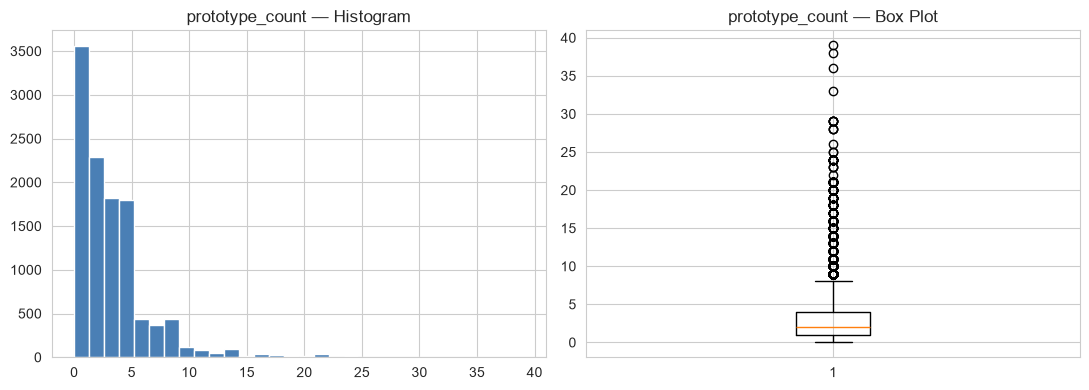

In [113]:
col = "prototype_count"
nonnull = df[col].dropna()
if len(nonnull) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(nonnull, bins=30, color='#4a7fb5')
    axes[0].set_title(f"{col} — Histogram")
    axes[1].boxplot(nonnull, vert=True)
    axes[1].set_title(f"{col} — Box Plot")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values to plot.")


## 3. Cross-Source Comparison

Only 3 of the 87 columns (`product_id`, `product_name`, `product_price`) are
populated by all 6 sources. This section compares fill rates for columns
that are shared across at least 2 sources, and concretely demonstrates the
"false-friend" columns identified during Stage 2 schema validation — same
column name, genuinely different value shape per source.

In [114]:
shared_cols = [c for c in df.columns if c not in ('source',)
               and df.groupby('source')[c].apply(lambda s: s.notna().any()).sum() >= 2]

fill_by_source = df.groupby('source').apply(
    lambda g: g[shared_cols].notna().mean() * 100
)
fill_by_source = fill_by_source.round(1)
fill_by_source.T.sort_values(by=fill_by_source.index[0], ascending=False)


source,CustomLinc,Fareharbor,Ingresso,Livn,Rezdy,Ventus
product_id,100.0,100.0,100.0,100.0,100.0,100.0
product_name,100.0,100.0,100.0,100.0,100.0,100.0
product_price,100.0,100.0,100.0,100.0,99.9,100.0
product_price_numeric,100.0,100.0,100.0,100.0,99.9,100.0
duration_display,100.0,0.0,0.0,0.0,93.3,0.0
product_category,100.0,0.0,100.0,100.0,0.0,100.0
product_currency,100.0,100.0,100.0,0.0,100.0,0.0
meta_supplier_id,100.0,0.0,100.0,100.0,100.0,0.0
meta_supplier_name,100.0,0.0,100.0,100.0,100.0,0.0
product_duration,100.0,28.7,0.0,100.0,94.4,0.0


### False-friend column: `product_price`

Same column name across all 6 sources, but Livn stores it as a **JSON list**
of `{amount, currency}` objects, while every other source stores a plain
numeric value. This is exactly why `product_price_numeric` was added as a
companion column during the unified-database merge — it normalizes Livn's
shape into a plain number so the rest of the column stays usable.

In [115]:
for src in df['source'].unique():
    sample = df.loc[df['source'] == src, 'product_price'].dropna()
    if len(sample):
        print(f"{src:12s}: {sample.iloc[0]!r}")


Rezdy       : '69.0'
Fareharbor  : '62.73'
Livn        : '[{"amount": 189, "currency": "AUD"}]'
CustomLinc  : '25'
Ventus      : '311.2'
Ingresso    : '24.0'


### False-friend column: `product_category`

Normalized to a consistent JSON string-list shape during the merge, but the
*original* per-source shapes were genuinely different before that
normalization: Livn used a list of `{id, name}` objects, CustomLinc/Ventus
used a single plain string, and Ingresso already used a list of strings.
The cell below shows the (already-normalized) values as they exist in this
CSV — all now directly comparable.

In [116]:
for src in df['source'].unique():
    sample = df.loc[df['source'] == src, 'product_category'].dropna()
    if len(sample):
        print(f"{src:12s}: {sample.iloc[0]!r}")


Livn        : '["Full Day Trips & Excursions", "National Parks & Natural Attractions", "Activities"]'
CustomLinc  : '["TOUR"]'
Ventus      : '["General Flight"]'
Ingresso    : '["Attractions", "Family"]'


### False-friend column: `location_country` / `product_currency`

Before normalization, sources used inconsistent casing and formats for the
same concept (`"au"` vs `"AU"` vs `"Australia"` for country;
`"aud"` vs `"AUD"` for currency). The unified database normalizes these to
uppercase ISO-style codes — shown below is the current, already-normalized
state.

In [117]:
print("location_country values by source:")
print(df.groupby('source')['location_country'].apply(lambda s: sorted(s.dropna().unique())))
print()
print("product_currency values by source:")
print(df.groupby('source')['product_currency'].apply(lambda s: sorted(s.dropna().unique())))


location_country values by source:
source
CustomLinc                                      []
Fareharbor                            [AU, NZ, TH]
Ingresso                              [AU, NZ, US]
Livn                                          [AU]
Rezdy         [AT, AU, ID, JP, MX, MY, NC, NF, NZ]
Ventus                                          []
Name: location_country, dtype: object

product_currency values by source:
source
CustomLinc                   [AUD]
Fareharbor              [AUD, NZD]
Ingresso                [AUD, NZD]
Livn                            []
Rezdy         [AUD, EUR, NZD, USD]
Ventus                          []
Name: product_currency, dtype: object


## 4. Data Quality Flags

### Most incomplete columns

In [118]:
missing_table.head(20)


,missing_count,missing_pct
package_groups,20816,100.0
package_type,20816,100.0
transfer_name,20815,100.0
transfer_pickup_hotels,20815,100.0
transfer_id,20815,100.0
detail_group_size,20813,100.0
pickup_locations_general,20812,100.0
meeting_point_notes,20807,99.9
booking_lead_time,20805,99.9
breakfast_details,20805,99.9


### Known per-source quirks and limitations

These are established findings from the pipeline's build history (Stage 1/
Stage 2 investigation and schema-validation work), not new discoveries from
this notebook — restated here for a single point of reference:

- **CustomLinc** has no description field at all (`webLongDesc`,
  `webShortDesc`, `webpageDesc` were all 100% empty at the raw source) — it
  is fundamentally a pricing/logistics feed, not a content source.
- **Ventus** has sparse descriptions (only ~37% of rows have any detail
  text) and no internal product ID in its source JSON — `product_id` for
  Ventus rows is derived entirely from the source filename.
- **Ingresso** is the smallest source (16 rows) and several of its fields
  are effectively constant across this snapshot (e.g. its cost-range
  min/max fields were identical on every row in the data available at
  build time) — real variation may appear in a larger future pull.
- **Livn** stores `product_price` as a JSON list rather than a scalar
  number (see the false-friend example in Section 3) — always prefer
  `product_price_numeric` for any numeric price comparison across sources.
- **Rezdy** and **Fareharbor** both required an AI-extraction pass to fill
  content-section gaps that their structured API fields alone did not
  cover — the `detail_*` text fields for these two sources are a mix of
  directly-sourced and AI-extracted text, though the underlying pipeline
  always preferred the dedicated API field when one existed.

In [119]:
for col in ['detail_description', 'product_price', 'location_latitude']:
    print(f"{col}:")
    print((df.groupby('source')[col].apply(lambda s: s.notna().mean() * 100)).round(1))
    print()


detail_description:
source
CustomLinc      0.0
Fareharbor     98.6
Ingresso       18.8
Livn          100.0
Rezdy          99.2
Ventus         36.8
Name: detail_description, dtype: float64

product_price:
source
CustomLinc    100.0
Fareharbor    100.0
Ingresso      100.0
Livn          100.0
Rezdy          99.9
Ventus        100.0
Name: product_price, dtype: float64

location_latitude:
source
CustomLinc      0.0
Fareharbor     62.1
Ingresso      100.0
Livn          100.0
Rezdy          99.7
Ventus          0.0
Name: location_latitude, dtype: float64



## 5. Summary / Key Takeaways

- The unified database is **wide but sparse by design** — only 3 of 87
  columns are populated across every source, because the 6 supplier
  schemas genuinely don't overlap much beyond product identity, name, and
  price.
- **Rezdy and Fareharbor dominate row count** (9,363 and 11,231 rows,
  ~99% of the dataset combined) — any aggregate statistic in this notebook
  is implicitly weighted toward these two sources unless explicitly
  grouped by `source`.
- The **false-friend columns** (`product_price`, `product_category`,
  currency/country casing) are the clearest reminder that a shared column
  name is not a guarantee of a shared value shape — `product_price_numeric`
  exists specifically to give downstream consumers one reliable numeric
  price column regardless of source.
- Several **content fields are sparse by nature of the source**, not by
  pipeline error (CustomLinc's missing descriptions, Ventus's sparse
  detail text, Ingresso's near-constant pricing fields in this snapshot) —
  worth remembering before treating a high missing-value % as a defect to
  fix rather than an accurate reflection of what each supplier actually
  provides.